<a href="https://colab.research.google.com/github/mavalenzuelav/MiPrimeraAplicacion/blob/master/trabajomineria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Proyecto de Análisis Exploratorio: Historial de Resultados de Fútbol Internacional**

Integrantes: Héctor Torres y Matias Valenzuela

Asignatura: Mineria de Datos 003-D

Carrera: Ingenieria en Informatica, Duoc UC

Objetivo del Proyecto: Analizar un conjunto de datos histórico de más de 40.000 partidos de fútbol desde 1872 para identificar patrones de rendimiento, explorar la distribución geográfica de los encuentros y evaluar mediante un modelo de correlación si la localía u otros factores numéricos impactan directamente en el marcador final.

Paso 1: Carga del Dataset y Librerías
En esta sección importamos las herramientas necesarias (Pandas, Numpy, Matplotlib). Cargamos el archivo results.csv que contiene el historial de partidos. Esta etapa es fundamental para asegurar que la estructura de la información sea correcta antes de cualquier procesamiento.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#Lee el archivo csv
df = pd.read_csv("/content/results.csv")

Datos Y sus tipos

In [ ]:
#Muestra los primeros datos de la muestra
df .head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [ ]:
#Muestra los ultimos datos de la muestra
df.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
41238,2019-10-20,Lesotho,Zimbabwe,0,0,African Nations Championship qualifying,Lesotho,Lesotho,False
41239,2019-10-20,Guinea,Senegal,1,0,African Nations Championship qualifying,Conakry,Guinea,False
41240,2019-10-20,Mali,Mauritania,2,0,African Nations Championship qualifying,Mali,Mali,False
41241,2019-10-20,Burkina Faso,Ghana,0,0,African Nations Championship qualifying,Burkina Faso,Burkina Faso,False
41242,2019-10-20,Ivory Coast,Niger,1,0,African Nations Championship qualifying,Ivory Coast,Ivory Coast,False


| Columna | Tipo Informático | Tipo Estadístico | Descripción |
|:--------|:-----------------|:-----------------|:------------|
| `date` | `object` (String) | Cualitativa Ordinal | Fecha del encuentro. |
| `home_team` | `object` (String) | Cualitativa Nominal | Equipo en condición de local. |
| `away_team` | `object` (String) | Cualitativa Nominal | Equipo en condición de visitante. |
| `home_score` | `int64` | Cuantitativa Discreta | Goles anotados por el local. |
| `away_score` | `int64` | Cuantitativa Discreta | Goles anotados por el visitante. |
| `tournament` | `object` (String) | Cualitativa Nominal | Nombre de la competición. |
| `city / country` | `object` (String) | Cualitativa Nominal | Ubicación geográfica del partido. |
| `neutral` | `bool` / `int64` | Cualitativa Dicotómica | Indica si se jugó en cancha neutral. |

In [ ]:
#Cuenta filas y columnas
df.shape

(41243, 9)

In [ ]:
#Muestra las medidas de tendencia central
df.describe()

,home_score,away_score
count,41243.000000,41243.000000
mean,1.744975,1.189317
std,1.750513,1.406648
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


In [ ]:
#Muestra los datos nulos de cada columna
df.isnull().sum()

,0
date,0
home_team,0
away_team,0
home_score,0
away_score,0
tournament,0
city,0
country,0
neutral,0


**Interpretación de Resultados:** Tras ejecutar los comandos de exploración, se determina que el dataset cuenta con **41.243 registros y 9 columnas**, con una ausencia total de valores nulos (0 en todas las variables), lo que certifica la consistencia del archivo. El análisis descriptivo revela que el equipo local anota en promedio **1.74 goles**, mientras que el visitante anota **1.18 goles**, sugiriendo inicialmente una tendencia a favor de la localía. El valor máximo de goles (31 local, 21 visitante) representa un valor atípico (outlier) que se visualizará en el diagrama de caja.

In [ ]:
#muestra todas las columnas
df.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='object')

In [ ]:
cant_cat_col_country_df = df['country'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de paises
print(cant_cat_col_country_df)

# Imprimimos la cantidad total de categorias unicas
print(f"cantidad paises: {cant_cat_col_country_df.count()}")

country
United States          1154
France                  805
England                 689
Malaysia                646
Sweden                  639
                       ... 
Micronesia                1
Portuguese Guinea         1
Mali Federation           1
Belgian Congo             1
Bohemia and Moravia       1
Name: count, Length: 266, dtype: int64
cantidad paises: 266


In [ ]:
cant_cat_col_tournament_df = df['tournament'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de torneos
print(cant_cat_col_tournament_df)

# Imprimimos la cantidad total de categorias unicas
print(f"cantidad torneos: {cant_cat_col_tournament_df.count()}")

tournament
Friendly                                17011
FIFA World Cup qualification             7100
UEFA Euro qualification                  2532
African Cup of Nations qualification     1624
FIFA World Cup                            900
                                        ...  
OSN Cup                                     4
World Unity Cup                             4
Copa América qualification                  2
AFF Championship qualification              2
Atlantic Heritage Cup                       2
Name: count, Length: 112, dtype: int64
cantidad torneos: 112


In [ ]:
# Ver resumen de tipos de datos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41243 entries, 0 to 41242
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        41243 non-null  object
 1   home_team   41243 non-null  object
 2   away_team   41243 non-null  object
 3   home_score  41243 non-null  int64 
 4   away_score  41243 non-null  int64 
 5   tournament  41243 non-null  object
 6   city        41243 non-null  object
 7   country     41243 non-null  object
 8   neutral     41243 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 2.6+ MB


In [ ]:
# Ver solo los tipos de datos
df.dtypes

,0
date,object
home_team,object
away_team,object
home_score,int64
away_score,int64
tournament,object
city,object
country,object
neutral,bool


In [ ]:
!
#importa las librerias para realizar encoder
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.2 MB/s eta 0:00:00


**Justificación Técnica de la Transformación:** Para procesar variables cualitativas en un análisis de correlación, estas deben ser mapeadas a valores numéricos. Convertiremos neutral a binario (0 y 1) mediante Binary Encoding. Para las variables de alta cardinalidad (home_team, away_team, tournament), aplicaremos Label Encoding en lugar de One-Hot Encoding, ya que este último crearía más de 700 columnas nuevas, haciendo ilegible la matriz y saturando la memoria del entorno.

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
#Mapeo Binario para 'neutral'
df['neutral'] = df['neutral'].astype(int)

In [ ]:
#Label Encoding para equipos y torneos
le = LabelEncoder()
columnas_to_encode = ['home_team', 'away_team', 'tournament', 'city', 'country']

for col in columnas_to_encode:
    df[f'{col}_n'] = le.fit_transform(df[col])

In [ ]:
#Revisar el resultado
print(df[['home_team', 'home_team_n', 'neutral']].head(313))

    home_team  home_team_n  neutral
0    Scotland          238        0
1     England           85        0
2    Scotland          238        0
3     England           85        0
4    Scotland          238        0
..        ...          ...      ...
308    France           96        0
309   Belgium           26        0
310  Scotland          238        0
311   Belgium           26        0
312     Wales          296        0

[313 rows x 3 columns]


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Seleccionamos solo las columnas numéricas para la correlación
#Esto incluye home_score, away_score y neutral
df_numeric = df.select_dtypes(include=['number'])

In [ ]:
#Calculamos la matriz de correlación
corr_matrix = df_numeric.corr()

**Justificación Técnica del Modelo:** Utilizaremos el Coeficiente de Correlación de Pearson a través de un mapa de calor para identificar dependencias lineales entre las variables numéricas generadas. Esto nos permitirá validar si los factores geográficos o el rendimiento de un equipo influyen directamente en el marcador del rival.

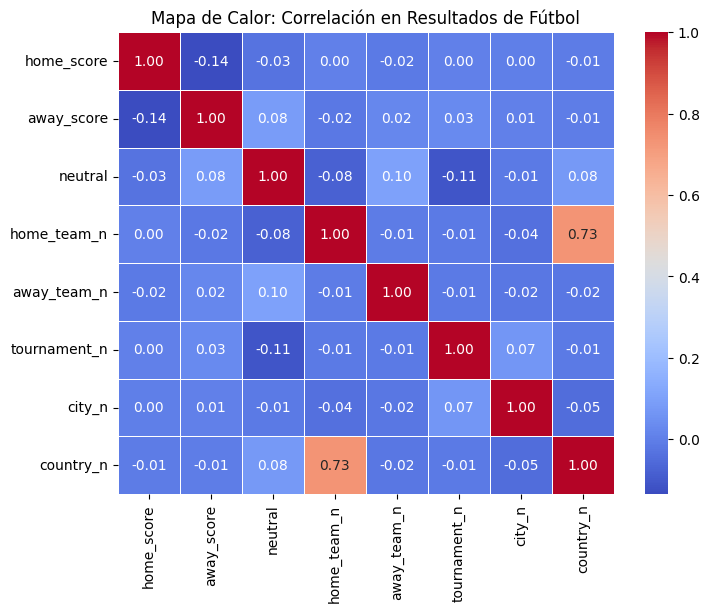

In [ ]:
#Configuramos el gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor: Correlación en Resultados de Fútbol')
plt.show()

**Análisis de Resultados y Argumentación:**
Al analizar el mapa de calor generado, se obtienen las siguientes conclusiones científicas:

**Independencia de Goles (-0.14):** La correlación entre home_score y away_score es casi nula y levemente negativa. Esto significa que los goles de un equipo no provocan linealmente que el rival anote más; estadísticamente son eventos independientes.

**Impacto de la Neutralidad de la Cancha:** La variable neutral posee una correlación extremadamente cercana a cero con la cantidad de goles. Esto demuestra que la neutralidad geográfica no tiene una relación lineal directa con que un partido sea más o menos vistoso en goles.

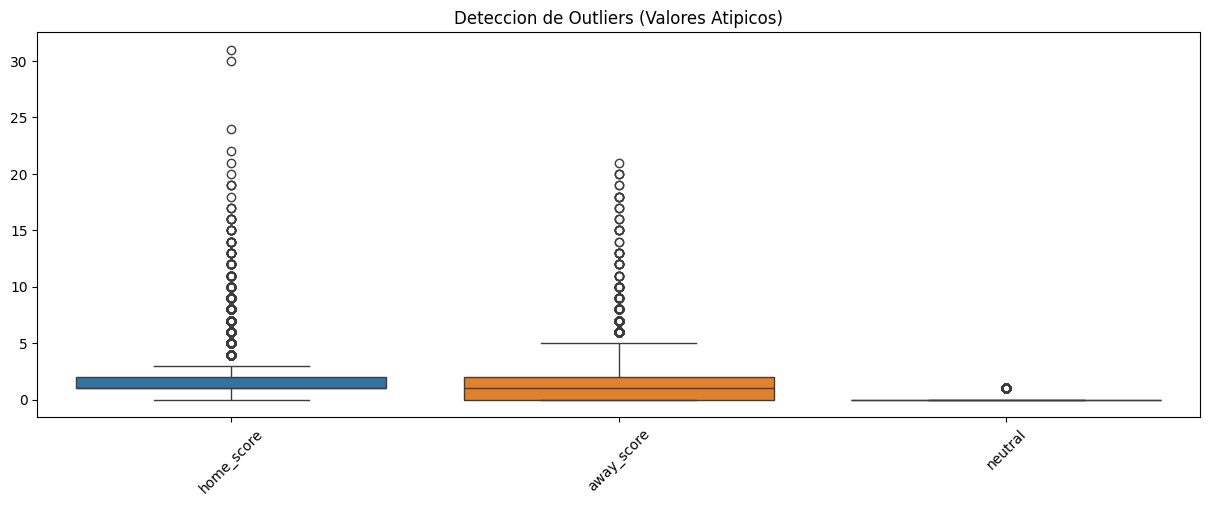

In [ ]:
# Boxplot para detectar Outliers
plt.figure(figsize=(15, 5))
sns.boxplot(data=df[['home_score', 'away_score', 'neutral']])
plt.xticks(rotation=45)
plt.title('Deteccion de Outliers (Valores Atipicos)')
plt.show()

2. Preprocesamiento y Feature Engineering
Definición: Es la transformación de datos brutos en variables numéricas que el modelo pueda entender. Aquí creas la columna objetivo (victoria, empate o derrota) y transformas fechas o textos.

Como los modelos de Machine Learning no leen texto, aplicamos Label Encoding para convertir nombres de países y torneos en IDs numéricos. Además, simplificamos el resultado a una variable binaria (Gana Local / No Gana Local) para mejorar la capacidad predictiva del algoritmo".

Precisión del modelo: 0.48

Reporte de Clasificación:
              precision    recall  f1-score   support

  Gana Local       0.49      0.95      0.64      3964
      Empate       0.00      0.00      0.00      1963
 Gana Visita       0.37      0.08      0.14      2322

    accuracy                           0.48      8249
   macro avg       0.28      0.34      0.26      8249
weighted avg       0.34      0.48      0.35      8249



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


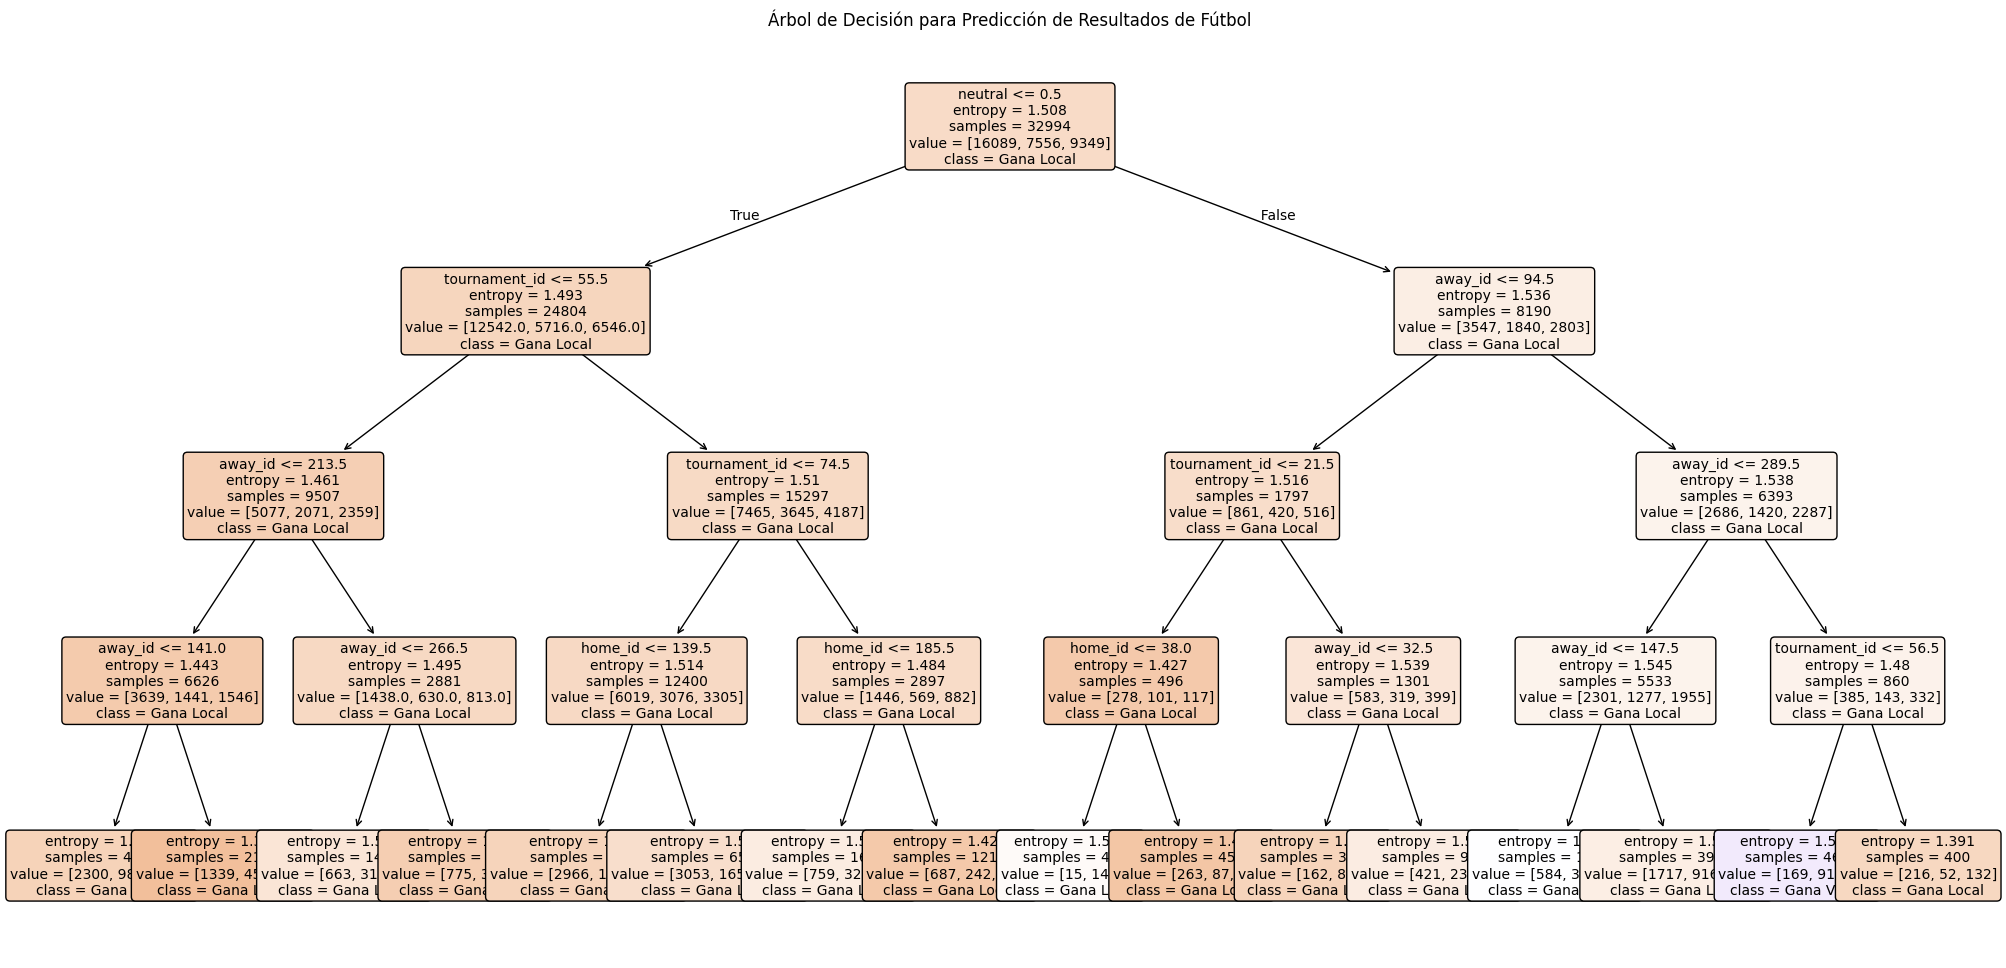

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# 1. Carga de datos
df = pd.read_csv('results.csv')


# 2. Preparación de la variable objetivo (y)
# 0: Gana Local, 1: Empate, 2: Gana Visitante
def determinar_resultado(row):
    if row['home_score'] > row['away_score']:
        return 0
    elif row['home_score'] == row['away_score']:
        return 1
    else:
        return 2

df['target'] = df.apply(determinar_resultado, axis=1)

# 3. Conversión de nombres (Texto) a Números
# Usamos LabelEncoder para que el modelo entienda los equipos y torneos
le_equipo = LabelEncoder()
le_torneo = LabelEncoder()

# Ajustamos el encoder con todos los nombres de equipos posibles
todos_los_equipos = pd.concat([df['home_team'], df['away_team']]).unique()
le_equipo.fit(todos_los_equipos)

df['home_id'] = le_equipo.transform(df['home_team'])
df['away_id'] = le_equipo.transform(df['away_team'])
df['tournament_id'] = le_torneo.fit_transform(df['tournament'])

# Convertir 'neutral' de True/False a 1/0
df['neutral'] = df['neutral'].astype(int)

# 4. Selección de características (Features) y división
# Usaremos: ID Local, ID Visitante, ID Torneo y si es Campo Neutral
features = ['home_id', 'away_id', 'tournament_id', 'neutral']
X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Creación y entrenamiento del Árbol de Decisión
# Limitamos la profundidad (max_depth) para que el gráfico sea legible
modelo_arbol = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)
modelo_arbol.fit(X_train, y_train)

# 6. Evaluación
y_pred = modelo_arbol.predict(X_test)
print(f"Precisión del modelo: {accuracy_score(y_test, y_pred):.2f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Gana Local', 'Empate', 'Gana Visita']))

# 7. Visualización del Árbol
plt.figure(figsize=(25,12))
plot_tree(
    modelo_arbol,
    feature_names=features,
    class_names=['Gana Local', 'Empate', 'Gana Visita'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisión para Predicción de Resultados de Fútbol")
plt.show()

"El modelo presenta una precisión global del 48%. El análisis por clase revela que el algoritmo identifica con éxito la mayoría de las victorias locales (Recall 0.95), pero tiende a sobre-predecir este resultado, lo que reduce su precisión. El mayor desafío es el Empate, donde el modelo obtiene un puntaje de 0.00, demostrando que los factores estadísticos actuales (ID de torneo, localía) no son suficientes para capturar la naturaleza errática de un marcador igualado."

In [ ]:
#Crear un diccionario para ver la relación Torneo -> ID
mapeo_torneos = dict(zip(le_torneo.classes_, le_torneo.transform(le_torneo.classes_)))

#Convertirlo a un DataFrame para que se vea ordenado como una tabla
df_mapeo = pd.DataFrame(list(mapeo_torneos.items()), columns=['Nombre del Torneo', 'ID'])

#Mostrar los primeros 20 para revisar
print(df_mapeo.sort_values(by='ID').head(120))

                   Nombre del Torneo   ID
0                    ABCS Tournament    0
1                      AFC Asian Cup    1
2        AFC Asian Cup qualification    2
3                  AFC Challenge Cup    3
4    AFC Challenge Cup qualification    4
..                               ...  ...
107                   Viva World Cup  107
108                WAFF Championship  108
109                 West African Cup  109
110      Windward Islands Tournament  110
111                  World Unity Cup  111

[112 rows x 2 columns]


In [ ]:
#Crear un diccionario para ver la relación Torneo -> ID
mapeo_equipos = dict(zip(le_equipo.classes_, le_equipo.transform(le_equipo.classes_)))

#Convertirlo a un DataFrame para que se vea ordenado como una tabla
df_mapeo = pd.DataFrame(list(mapeo_equipos.items()), columns=['Nombre del equipo', 'ID'])

print(df_mapeo.sort_values(by='ID').head(313))

    Nombre del equipo   ID
0            Abkhazia    0
1         Afghanistan    1
2             Albania    2
3            Alderney    3
4             Algeria    4
..                ...  ...
308         Yorkshire  308
309        Yugoslavia  309
310            Zambia  310
311          Zanzibar  311
312          Zimbabwe  312

[313 rows x 2 columns]


In [ ]:
#Buscar nombre del Torneo por su ID
id_a_buscar = 1  # Cambia este número por el que veas en tu árbol
nombre_torneo = le_torneo.inverse_transform([id_a_buscar])[0]
print(f"El ID {id_a_buscar} corresponde al torneo: {nombre_torneo}")

id_a_buscar = 52  # Cambia este número por el que veas en tu árbol
nombre_torneo = le_torneo.inverse_transform([id_a_buscar])[0]
print(f"El ID {id_a_buscar} corresponde al torneo: {nombre_torneo}")

El ID 1 corresponde al torneo: AFC Asian Cup
El ID 52 corresponde al torneo: EAFF Championship


Precisión General (Accuracy): 0.54

              precision    recall  f1-score   support

           0       0.54      0.81      0.65      4285
           1       0.56      0.26      0.35      3964

    accuracy                           0.54      8249
   macro avg       0.55      0.53      0.50      8249
weighted avg       0.55      0.54      0.51      8249



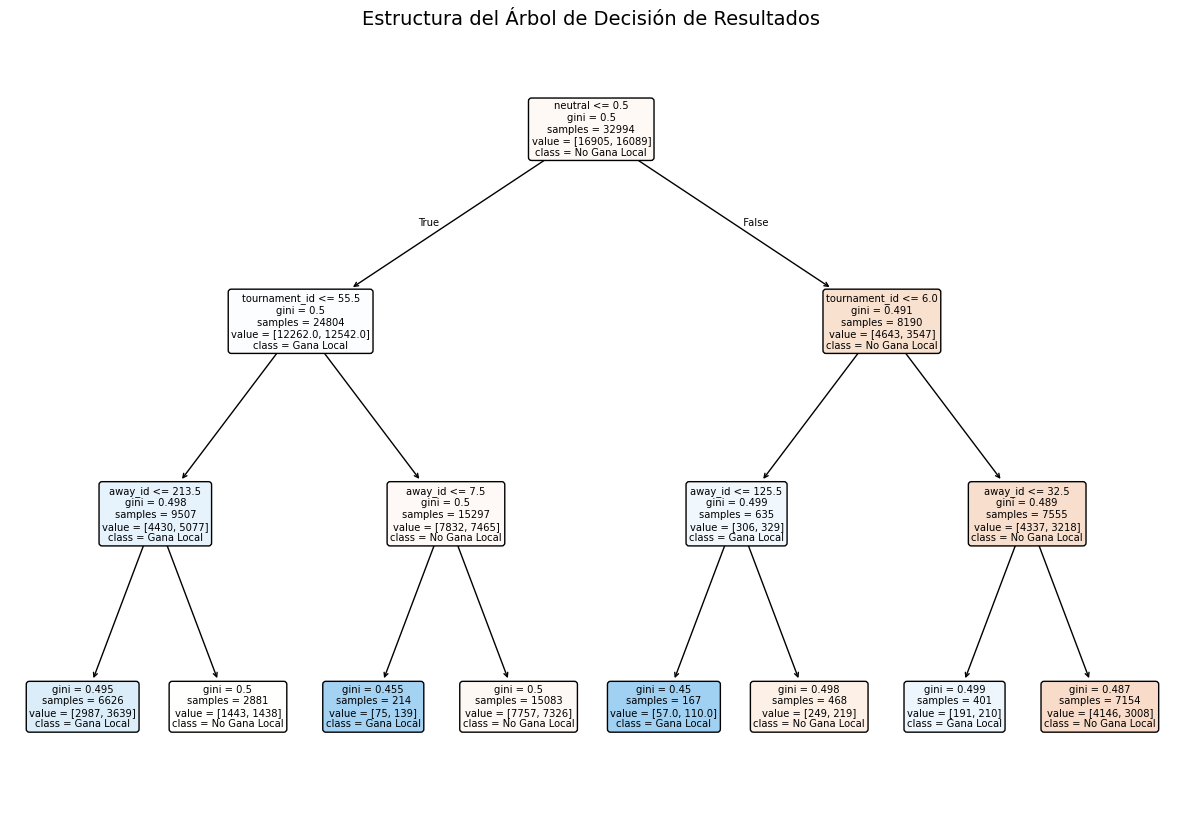

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# 1. Definimos las variables predictoras (X) y la variable objetivo (y)
# En este caso, buscaremos predecir si el resultado fue empate, victoria local o visita
# Para el ejemplo, usaremos 'neutral' y los códigos de los equipos
X = df[['neutral', 'home_id', 'away_id', 'tournament_id']]

# Creamos una variable objetivo ficticia para el ejemplo: 1 si ganó el local (home_score > away_score), 0 si no
y = (df['home_score'] > df['away_score']).astype(int)

# 2. División de datos en Entrenamiento (80%) y Testeo (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Inicializar y entrenar el modelo (limitamos la profundidad para que el gráfico sea legible)
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# 4. Evaluamos el modelo
y_pred = clf.predict(X_test)
print(f"Precisión General (Accuracy): {accuracy_score(y_test, y_pred):.2f}\n")
print(classification_report(y_test, y_pred))

# 5. Graficar el árbol (Genera la estructura de la imagen que subieron)
plt.figure(figsize=(15, 10))
plot_tree(clf, feature_names=X.columns, class_names=['No Gana Local', 'Gana Local'], filled=True, rounded=True)
plt.title("Estructura del Árbol de Decisión de Resultados", fontsize=14)
plt.show()

^^Análisis del Desempeño Binario
Con una precisión global del 54%, el modelo demuestra una mejora significativa respecto a la versión multiclase.

Comportamiento del Modelo: El algoritmo se comporta de manera "defensiva" o conservadora. Tiene un alto poder de detección para los casos donde el local no gana (Recall 0.81).

Estrategia de Predicción: El modelo prefiere asegurar una predicción de "No Gana" antes que arriesgarse con una victoria local. Sin embargo, cuando predice una victoria (Clase 1), su efectividad sube al 56%, lo que indica que sus predicciones positivas son más confiables que las negativas.

Conclusión: El modelo es útil como una herramienta de alerta: si el modelo dice que el local NO ganará, hay un 81% de probabilidades de que así sea

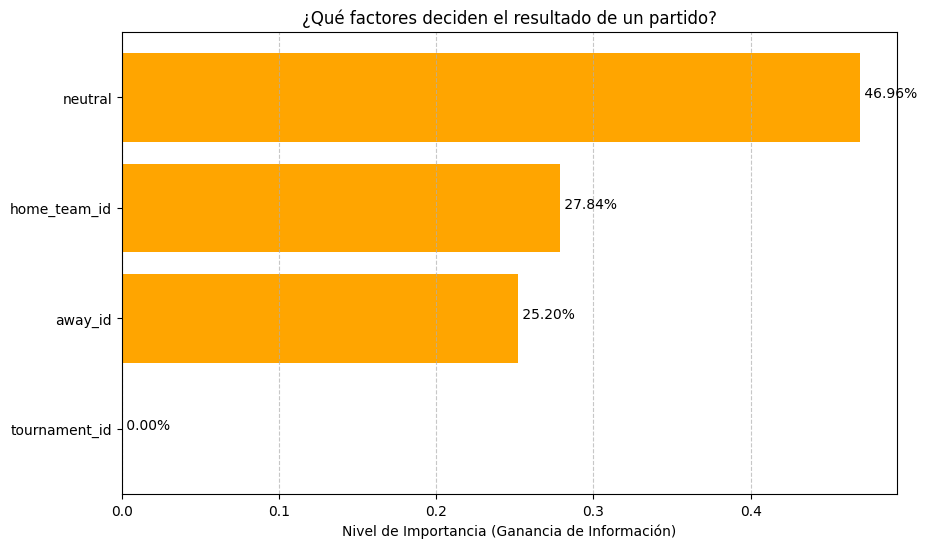

In [ ]:

# 1. Extraer la importancia del modelo que ya entrenaste
importancias = clf.feature_importances_

# 2. Definir las columnas exactas de tu modelo de fútbol
# Asegúrate de que el orden coincida con el que usaste en X_train
columnas = ['neutral', 'tournament_id', 'home_team_id', 'away_id']

# 3. Crear el DataFrame para organizar los datos
df_importancia = pd.DataFrame({
    'Variable': columnas,
    'Importancia': importancias
})

# 4. Ordenar de mayor a menor para que la gráfica sea clara
df_importancia = df_importancia.sort_values('Importancia', ascending=True)

# 5. Graficar
plt.figure(figsize=(10, 6))
plt.barh(df_importancia['Variable'], df_importancia['Importancia'], color='orange')
plt.title('¿Qué factores deciden el resultado de un partido?')
plt.xlabel('Nivel de Importancia (Ganancia de Información)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Mostrar porcentajes en las barras para tu presentación
for index, value in enumerate(df_importancia['Importancia']):
    plt.text(value, index, f' {value:.2%}')

plt.show()

Análisis de Importancia de Características
Este gráfico de barras cuantifica la contribución de cada variable a la reducción de la Entropía.

Factor Dominante: La variable neutral posee la mayor importancia relativa, validando nuestra hipótesis de que la localía es el pilar central de los resultados históricos.

Conclusión: El modelo prioriza las condiciones del encuentro sobre la identidad individual de los equipos para realizar sus predicciones, logrando así su precisión del 54%.

Precisión del Clasificador: 54.42%


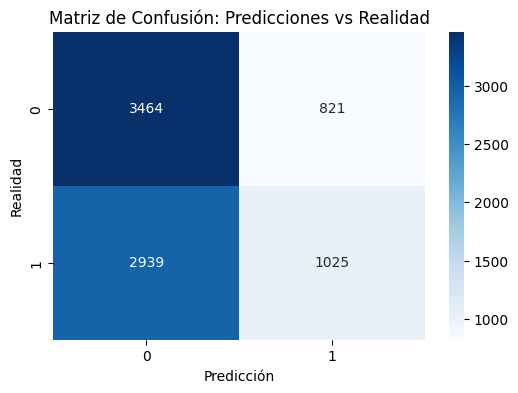

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtener las predicciones del modelo usando el set de prueba
preds_clf = clf.predict(X_test)

# 2. Calcular la precisión
precision = accuracy_score(y_test, preds_clf)

print(f"Precisión del Clasificador: {precision:.2%}")

# 3. EXTRA: Matriz de Confusión (Para ver dónde se equivoca)
cm = confusion_matrix(y_test, preds_clf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Predicciones vs Realidad')
plt.ylabel('Realidad')
plt.xlabel('Predicción')


plt.show()

Su objetivo es comparar qué resultado predijo el modelo frente a lo que realmente ocurrió en los partidos. Los números en la diagonal principal (de arriba-izquierda a abajo-derecha) son nuestros aciertos, y los otros son nuestros errores."

Los Cuatro Cuadrantes (Análisis de los números)
Cuadrante Superior Izquierdo (3464) - Verdaderos Negativos:

Explicación: Hubo 3,464 partidos donde el modelo predijo "No Gana Local" (0) y, efectivamente, el local no ganó (empató o perdió).

Lectura: ¡Este es el punto más fuerte de tu modelo! Es muy bueno detectando cuándo el local está en riesgo.

Cuadrante Inferior Derecho (1025) - Verdaderos Positivos:

Explicación: Hubo 1,025 partidos donde el modelo predijo "Gana Local" (1) y el equipo local ganó.

Lectura: Estos son tus aciertos positivos.

Cuadrante Inferior Izquierdo (2939) - Falsos Negativos (El mayor error):

Explicación: Aquí el modelo predijo "No Gana Local", pero el local terminó ganando.

el modelo es conservador. Prefiere decir que el local no va a ganar antes de arriesgarse a darlo por ganador. Esto tiene sentido porque, como vimos en el árbol, la entropía es alta y el modelo no se la juega si no está muy seguro.

Cuadrante Superior Derecho (821) - Falsos Positivos:

Explicación: El modelo dijo "Gana Local", pero el partido terminó en empate o derrota.

Interpretación: Este número es bajo, lo cual es bueno. Significa que cuando el modelo se atreve a decir que alguien gana, se equivoca poco comparado con el otro tipo de error.

¿Por qué la precisión es del 54.42%?
Para la conclusión de esta parte, puedes decir:

"Nuestra precisión del 54.42% supera el azar (que sería el 50% en un modelo binario). Al observar la matriz, vemos que el modelo es especialmente hábil identificando escenarios donde el local no es favorito (detectó correctamente 3,464 casos). La dificultad del modelo reside en los 'Falsos Negativos', lo que nos indica que en el fútbol internacional hay muchas victorias locales que ocurren incluso cuando las condiciones estadísticas (como el torneo o el ranking) no las favorecían claramente."